<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/DBSCAN_Perbandingan_Distance_Metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis Metrik Jarak & Prinsip DBSCAN

| Metrik | Rumus jarak |
| --- | --- |
| Euclidean | $d(x,y)=\sqrt{\sum_i(x_i-y_i)^2}$ |
| Manhattan | $d(x,y)=\sum_i|x_i-y_i|$ |
| Cosine | $d(x,y)=1-\frac{x\cdot y}{\lVert x\rVert_2\lVert y\rVert_2}$ |

DBSCAN membentuk klaster dari lingkungan padat:
$$N_\varepsilon(x)=\{y:d(x,y)\leq\varepsilon\},\qquad
|N_\varepsilon(x)|\geq\mathrm{min\_samples}.$$
Label `-1` menunjukkan noise. Semua metrik menggunakan seluruh baris dan
fitur hasil StandardScaler, serta `EPS`, `MIN_SAMPLES`, `algorithm`, dan
`n_jobs` yang sama. PCA menggunakan koordinat yang sama untuk visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

import gc
import time
import tracemalloc


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING BERSAMA
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


## 📈 2. Penetapan Parameter DBSCAN

Parameter notebook awal dipertahankan: `EPS = 0.5`, `MIN_SAMPLES = 5`,
`algorithm="brute"`, dan `n_jobs=1`.
`EPS` menentukan radius lingkungan; `MIN_SAMPLES` menentukan kepadatan
minimum. Jumlah klaster diperoleh dari hubungan kepadatan data.


Nilai radius yang sama membandingkan perilaku tiap metrik dengan parameter
tetap. Skala dan geometri jarak tiap metrik dapat menghasilkan jumlah
klaster serta noise yang berbeda. Silhouette dihitung pada seluruh data
non-noise ketika terdapat setidaknya dua klaster dan jumlah klaster lebih
kecil daripada jumlah data evaluasi.

Waktu dan puncak memori `tracemalloc` diukur selama `fit_predict()`;
Silhouette dihitung sesudah pengukuran fit. Memori yang dilaporkan merupakan
puncak alokasi yang terlacak, dalam MiB.

In [ ]:
# =======================================================================
# 3. PARAMETER PENGUJIAN TIGA METRIK
# =======================================================================
DISTANCE_METRICS = [
    "euclidean",
    "manhattan",
    "cosine",
]

EPS = 0.5
MIN_SAMPLES = 5

print("Distance metrics :", DISTANCE_METRICS)
print("EPS              :", EPS)
print("MIN_SAMPLES      :", MIN_SAMPLES)


Distance metrics : ['euclidean', 'manhattan', 'cosine']
EPS              : 0.5
MIN_SAMPLES      : 5


In [ ]:
# =======================================================================
# 4. FUNGSI BENCHMARK DBSCAN
# =======================================================================
def benchmark_dbscan(X_data, metric, eps, min_samples):
    gc.collect()

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric,
        algorithm="brute",
        n_jobs=1
    )

    tracemalloc.start()
    start_time = time.perf_counter()

    cluster_labels = model.fit_predict(X_data)

    execution_time = time.perf_counter() - start_time
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    peak_memory_mb = peak_memory / (1024 ** 2)

    noise_mask = cluster_labels == -1
    n_clusters = len(set(cluster_labels)) - int(noise_mask.any())

    X_evaluation = X_data[~noise_mask]
    labels_evaluation = cluster_labels[~noise_mask]
    n_evaluation_clusters = len(np.unique(labels_evaluation))

    silhouette = np.nan

    if (
        len(labels_evaluation) > 1
        and 2 <= n_evaluation_clusters < len(labels_evaluation)
    ):
        silhouette = silhouette_score(
            X_evaluation,
            labels_evaluation,
            metric=metric
        )

    core_mask = np.zeros(len(cluster_labels), dtype=bool)
    core_mask[model.core_sample_indices_] = True
    border_mask = (~noise_mask) & (~core_mask)

    result = {
        "Distance Metric": metric.title(),
        "Jumlah Kluster": n_clusters,
        "Core Point": int(core_mask.sum()),
        "Border Point": int(border_mask.sum()),
        "Noise": int(noise_mask.sum()),
        "Noise (%)": 100 * noise_mask.mean(),
        "Waktu Eksekusi (detik)": execution_time,
        "Silhouette Score": silhouette,
        "Penggunaan Memori (MiB)": peak_memory_mb,
    }

    return result, cluster_labels


In [ ]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING & TABEL PERBANDINGAN
# =======================================================================
results = []
cluster_labels_by_metric = {}

for metric in DISTANCE_METRICS:
    print(f"Menjalankan DBSCAN dengan metric = {metric} ...")

    result, cluster_labels = benchmark_dbscan(
        X_data=X_scaled,
        metric=metric,
        eps=EPS,
        min_samples=MIN_SAMPLES
    )

    results.append(result)
    cluster_labels_by_metric[metric] = cluster_labels

print("Selesai.")

comparison_df = pd.DataFrame(results)

comparison_df["Waktu Eksekusi (detik)"] = (
    comparison_df["Waktu Eksekusi (detik)"].round(4)
)

comparison_df["Silhouette Score"] = (
    comparison_df["Silhouette Score"].round(4)
)

comparison_df["Penggunaan Memori (MiB)"] = (
    comparison_df["Penggunaan Memori (MiB)"].round(4)
)

display(comparison_df)


Menjalankan DBSCAN dengan metric = euclidean ...


Menjalankan DBSCAN dengan metric = manhattan ...


Menjalankan DBSCAN dengan metric = cosine ...


Selesai.


,Distance Metric,Jumlah Kluster,Core Point,Border Point,Noise,Noise (%),Waktu Eksekusi (detik),Silhouette Score,Penggunaan Memori (MiB)
0,Euclidean,58,509,120,10801,94.496938,0.1836,0.6842,16.3823
1,Manhattan,30,277,79,11074,96.885389,0.5023,0.8311,15.9662
2,Cosine,5,11422,2,6,0.052493,0.6428,-0.0097,2381.4033


Explained variance PC1 + PC2: 0.1551
PC1: 0.1014
PC2: 0.0537


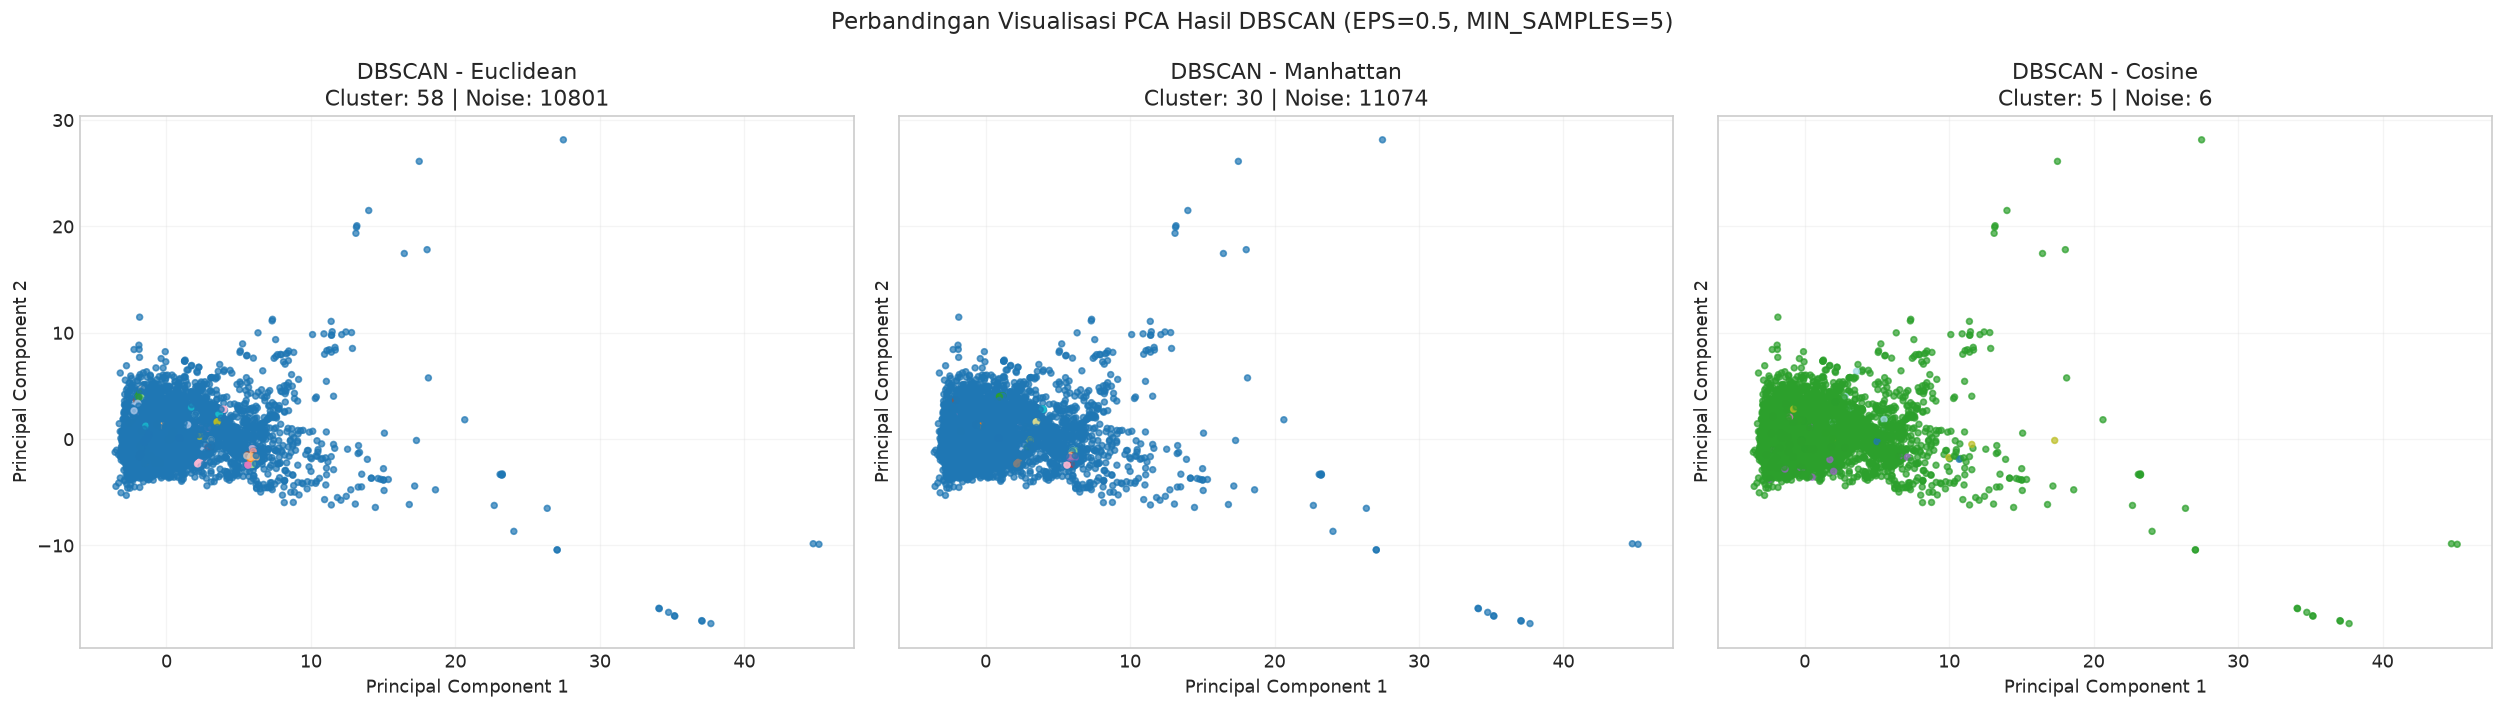

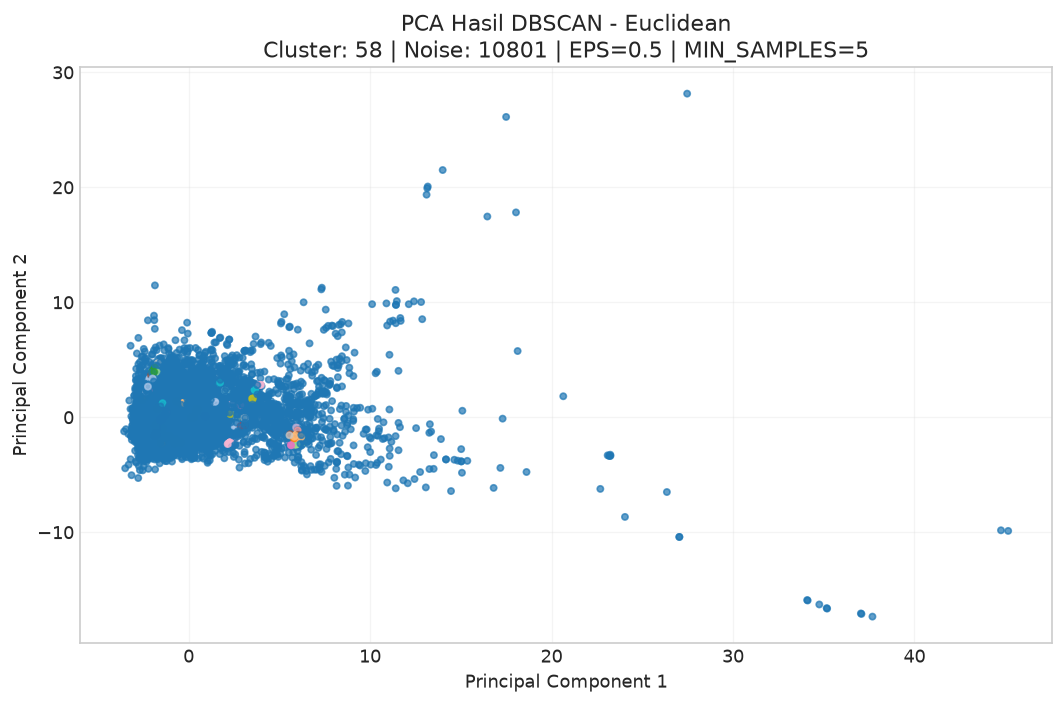

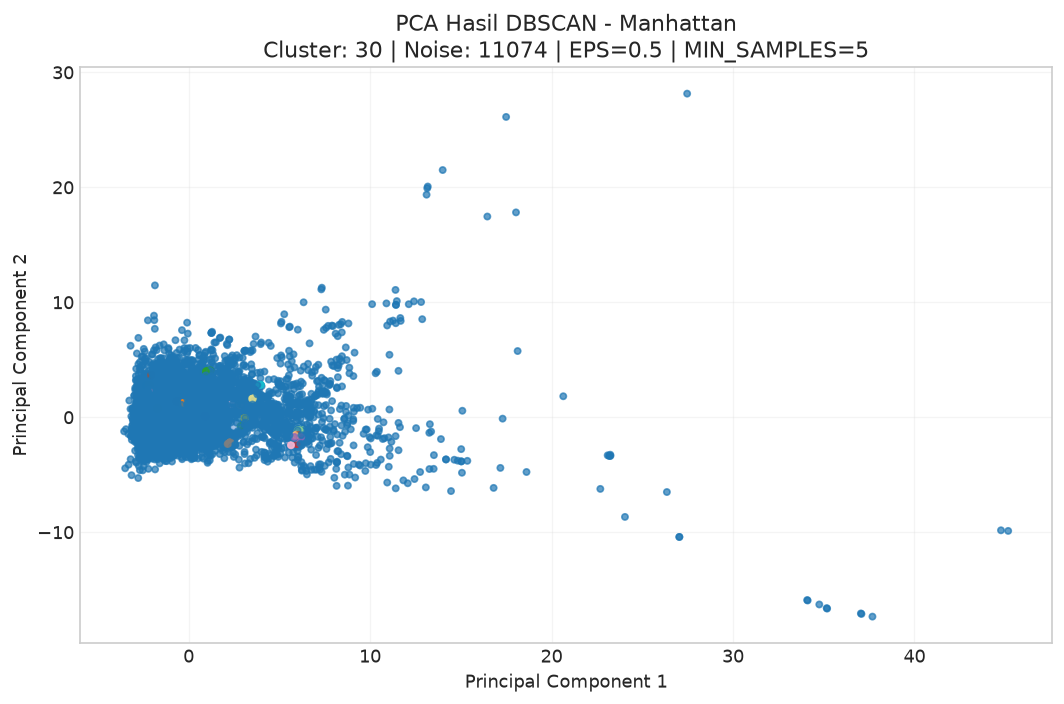

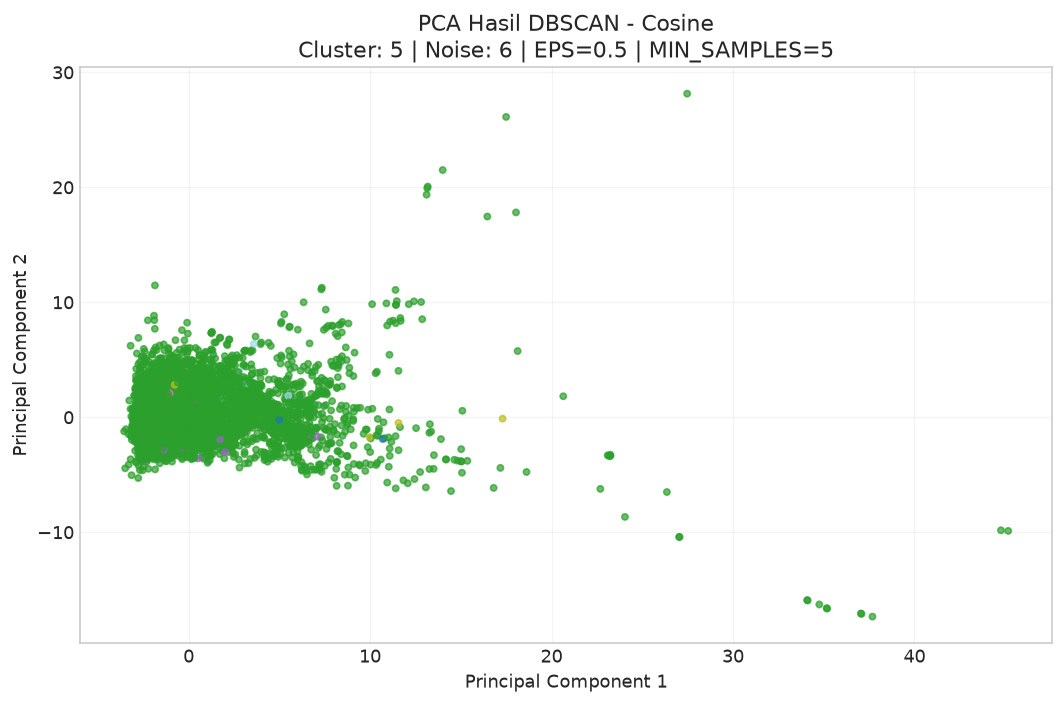

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PERBANDINGAN KLASTER & NOISE
# =======================================================================
pca = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance PC1 + PC2:", round(pca.explained_variance_ratio_.sum(), 4))
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

for ax, metric in zip(axes, DISTANCE_METRICS):
    cluster_labels = cluster_labels_by_metric[metric]

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap="tab20",
        s=12,
        alpha=0.7
    )

    n_clusters = len(set(cluster_labels)) - int(-1 in cluster_labels)
    n_noise = np.sum(cluster_labels == -1)

    ax.set_title(
        f"DBSCAN - {metric.title()}\n"
        f"Cluster: {n_clusters} | Noise: {n_noise}"
    )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.2)

plt.suptitle(
    f"Perbandingan Visualisasi PCA Hasil DBSCAN "
    f"(EPS={EPS}, MIN_SAMPLES={MIN_SAMPLES})",
    fontsize=14
)
plt.tight_layout()
plt.show()

for metric in DISTANCE_METRICS:
    cluster_labels = cluster_labels_by_metric[metric]
    n_clusters = len(set(cluster_labels)) - int(-1 in cluster_labels)
    n_noise = np.sum(cluster_labels == -1)

    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap="tab20",
        s=14,
        alpha=0.7
    )
    plt.title(
        f"PCA Hasil DBSCAN - {metric.title()}\n"
        f"Cluster: {n_clusters} | Noise: {n_noise} | "
        f"EPS={EPS} | MIN_SAMPLES={MIN_SAMPLES}"
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


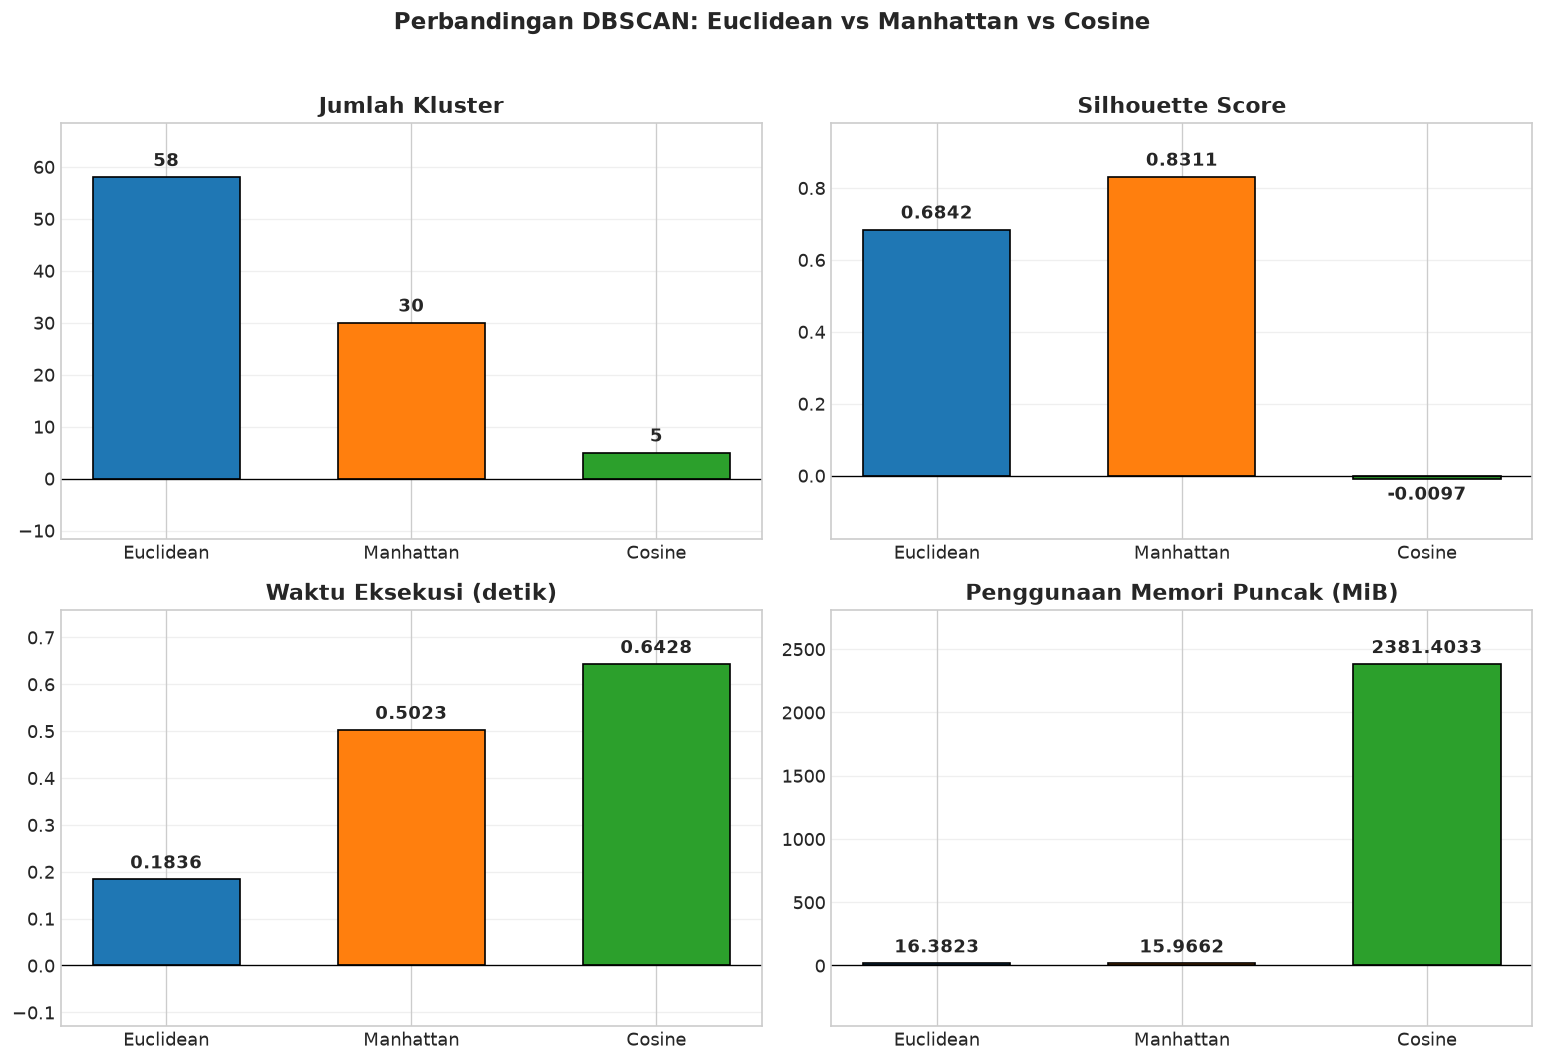

In [ ]:
# =======================================================================
# 7. DIAGRAM BATANG PERBANDINGAN EVALUASI & KINERJA
# =======================================================================
# Urutan dan warna mengikuti notebook referensi
nama = comparison_df["Distance Metric"].tolist()
warna = ["tab:blue", "tab:orange", "tab:green"]

panel = [
    ("Jumlah Kluster", "Jumlah Kluster", "{:.0f}"),
    ("Silhouette Score", "Silhouette Score", "{:.4f}"),
    ("Waktu Eksekusi (detik)", "Waktu Eksekusi (detik)", "{:.4f}"),
    ("Penggunaan Memori (MiB)", "Penggunaan Memori Puncak (MiB)", "{:.4f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (kolom, judul, fmt) in zip(axes.ravel(), panel):
    nilai = comparison_df[kolom].to_numpy(dtype=float)

    bars = ax.bar(
        nama,
        np.where(np.isfinite(nilai), nilai, 0),
        color=warna,
        edgecolor="black",
        width=0.6
    )

    ax.set_title(judul, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)

    nilai_valid = nilai[np.isfinite(nilai)]
    if len(nilai_valid) > 0:
        batas = max(np.max(np.abs(nilai_valid)), 1e-9)
        ymin = min(0, np.min(nilai_valid)) - 0.20 * batas
        ymax = np.max(nilai_valid) + 0.18 * batas
        if np.isclose(ymin, ymax):
            ymax = ymin + 1
        ax.set_ylim(ymin, ymax)

    for bar, value in zip(bars, nilai):
        if np.isfinite(value):
            ax.annotate(
                fmt.format(value),
                (bar.get_x() + bar.get_width() / 2, value),
                ha="center",
                va="bottom" if value >= 0 else "top",
                xytext=(0, 4 if value >= 0 else -4),
                textcoords="offset points",
                fontweight="bold"
            )
        else:
            ax.annotate(
                "N/A",
                (bar.get_x() + bar.get_width() / 2, 0),
                ha="center",
                va="bottom",
                xytext=(0, 4),
                textcoords="offset points",
                fontweight="bold"
            )

fig.suptitle(
    "Perbandingan DBSCAN: Euclidean vs Manhattan vs Cosine",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# =======================================================================
# 8. INTERPRETASI HASIL PERBANDINGAN
# =======================================================================
print('INTERPRETASI HASIL PERBANDINGAN DBSCAN')
for _, row in comparison_df.iterrows():
    score = row['Silhouette Score']
    score_text = f'{score:.4f}' if np.isfinite(score) else 'N/A (jumlah klaster non-noise tidak memenuhi syarat)'
    print(f"{row['Distance Metric']}: {int(row['Jumlah Kluster'])} klaster, "
          f"{int(row['Noise'])} noise ({row['Noise (%)']:.2f}%), Silhouette = {score_text}")
print('Silhouette tiap baris memakai geometri metriknya sendiri; jumlah data non-noise dapat berbeda.')
print('Waktu fit tidak mencakup Silhouette. Memori merupakan peak tracked memory tracemalloc dalam MiB.')
print('PCA hanya untuk visualisasi; proses clustering memakai seluruh fitur setelah StandardScaler.')


INTERPRETASI HASIL PERBANDINGAN DBSCAN
Euclidean: 58 klaster, 10801 noise (94.50%), Silhouette = 0.6842
Manhattan: 30 klaster, 11074 noise (96.89%), Silhouette = 0.8311
Cosine: 5 klaster, 6 noise (0.05%), Silhouette = -0.0097
Silhouette tiap baris memakai geometri metriknya sendiri; jumlah data non-noise dapat berbeda.
Waktu fit tidak mencakup Silhouette. Memori merupakan peak tracked memory tracemalloc dalam MiB.
PCA hanya untuk visualisasi; proses clustering memakai seluruh fitur setelah StandardScaler.
